# W + Charm Analysis:

This analysis is done using `Coffea` (version 2024.10.0) and `Awkward Arrays`. This study will focus on the event selection of W+c Events. This analysis will focus on the selection of W+c Events. The dataset used for this is: [W1JetsToLNu_TuneCP5_13TeV-madgraphMLM-pythia8/RunIISummer20UL16NanoAODv9-106X_mcRun2_asymptotic_v17-v1/NANOAODSIM](https://opendata.cern.ch/record/69545).

In [1]:
import hist as h
import dask
import awkward as ak
import hist.dask as dhist
import dask_awkward as dak
import uproot
import numpy as np
import mplhep as mh
from coffea import processor
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import matplotlib.pyplot as plt

NanoAODSchema.warn_missing_crossrefs = False

In [2]:
events = NanoEventsFactory.from_root(
    {"../../datasets/nano106X_on_mini106X_2017_mc_NANOAOD_W1Jets_to_LNu_1M.root": "Events"},
    schemaclass=NanoAODSchema,
    metadata={"dataset":"WJets"},
    mode="dask"
).events()
events

dask.awkward<from-uproot, npartitions=1>

In [3]:
# Defining the style for plots (CMS Style)
from mplhep.plot import AnchoredText


plt.style.use(mh.style.CMS)
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})


In [4]:
# Histogram Function:
def make_hist(
        data, nBins, lo, hi, xlabel, ylabel, label, fname=None, logy=False, ax=None, show=True, return_hist=False, show_stats=True, histtype='step'
):
    histogram = dhist.Hist(h.axis.Regular(nBins, lo, hi))
    if ax is None:
        fig, ax = plt.subplots(1,1, figsize=(6, 4))
    else:
        fig = ax.figure
    histogram.fill(data)
    hist_comp = histogram.compute()

    mh.histplot(hist_comp, ax=ax, label=label, histtype=histtype, lw=1)
    mh.cms.label("Open Data", data=False, lumi=None, com=13, year=2016, loc=0)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()

    # log scale option:
    if logy:
        ax.set_yscale("log")

    # Statbox option:
    if show_stats:
        n_entries = len(data.compute())
        mean_val = np.mean(data.compute())
        std_val = np.std(data.compute())
        stat_text = (f"Entries: {n_entries}\n"
                     f"Mean:    {mean_val:.2f}\n"
                     f"Std Dev: {std_val:.2f}")
        at = AnchoredText(stat_text, prop=dict(size=10), frameon=True, loc="center right")
        ax.add_artist(at)

    # Save figure option:
    if fname:
        plt.savefig(fname)

    # Show figure option:
    if show:
        plt.show()

    if return_hist:
        return fig, ax, hist_comp
    return fig, ax

In [5]:
# Making Difference Histogram Function:
def make_diff_hist(
    a, b, *, bins=50, lo=0, hi=200, ylo=-1, yhi=2000, name="x",
    xlabel=None, ylabel="Entries", title=None, diff_label="A - B", color="k", histtype="errorbar", yerr=False, zero_line=True, normalize=False, weights_a=None,weights_b=None, flatten=False, cms_label=True, ax=None,
    figsize=(7, 5), grid=True, show=True, fname=None,
    return_hists=False,
):
    # Detect hist input
    try:
        from hist.basehist import BaseHist
        a_is_hist = isinstance(a, BaseHist)
        b_is_hist = isinstance(b, BaseHist)
    except Exception:
        a_is_hist = False
        b_is_hist = False

    def _prep(x):
        if flatten:
            try:
                return dak.flatten(x)
            except Exception:
                return x
        return x

    # Build/obtain hA and hB
    if a_is_hist and b_is_hist:
        hA = a
        hB = b
    elif (not a_is_hist) and (not b_is_hist):
        axis = h.axis.Regular(
            bins, lo, hi,
            name=name,
            label=(xlabel if xlabel is not None else name),
        )
        hA_d = h.dask.Hist(axis)
        hB_d = h.dask.Hist(axis)

        xA = _prep(a)
        xB = _prep(b)

        if weights_a is None:
            hA_d.fill(**{name: xA})
        else:
            hA_d.fill(**{name: xA}, weight=_prep(weights_a))

        if weights_b is None:
            hB_d.fill(**{name: xB})
        else:
            hB_d.fill(**{name: xB}, weight=_prep(weights_b))

        hA = hA_d.compute()
        hB = hB_d.compute()
    else:
        raise TypeError("make_diff_hist: both inputs must be arrays OR both must be hist objects.")

    if normalize:
        sA = float(hA.values().sum())
        sB = float(hB.values().sum())
        if sA > 0:
            hA = hA / sA
        if sB > 0:
            hB = hB / sB

    hDiff = hA - hB

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    if cms_label:
        mh.cms.label("Open Data", data=True, lumi=None, com=13, year=2016, loc=0)

    mh.histplot(hDiff, ax=ax, label=diff_label, histtype=histtype, color=color, yerr=yerr)

    if zero_line:
        ax.axhline(0.0, color="0.5", lw=1, linestyle="--")

    if title:
        ax.set_title(title)

    ax.set_xlabel(xlabel if xlabel is not None else name)
    ax.set_ylabel(ylabel)
    ax.set_ylim(ylo, yhi)
    ax.legend()
    if grid:
        ax.grid(True, alpha=0.3)
    if fname:
        plt.savefig(fname)
    if show:
        plt.show()

    if return_hists:
        return fig, ax, hDiff, hA, hB
    return fig, ax, hDiff

In [6]:
# Overlay Histogram Function:
def make_overlay_hist(
    data_a, data_b, *, bins=50, x_range=(0, 200), name="x",
    histtype="step", xlabel=None, ylabel=None, title=None,
    normalize=True, labels=("A", "B"), colors=("C0", "C1"),
    weights_a=None, weights_b=None, flatten=False, cms_label=True, ax=None, figsize=(7, 5), grid=True,
    fname=None, show=True, yerr=False, linewidth=1.5,     
):
    def _prep(x):
        if flatten:
            try:
                return dak.flatten(x)
            except Exception:
                return x
        return x

    axis = h.axis.Regular(
        bins, x_range[0], x_range[1],
        name=name,
        label=(xlabel if xlabel is not None else name),
    )

    hA_d = h.dask.Hist(axis)
    hB_d = h.dask.Hist(axis)

    xA = _prep(data_a)
    xB = _prep(data_b)

    if weights_a is None:
        hA_d.fill(**{name: xA})
    else:
        hA_d.fill(**{name: xA}, weight=_prep(weights_a))

    if weights_b is None:
        hB_d.fill(**{name: xB})
    else:
        hB_d.fill(**{name: xB}, weight=_prep(weights_b))

    hA = hA_d.compute()
    hB = hB_d.compute()

    if normalize:
        sA = float(hA.values().sum())
        sB = float(hB.values().sum())
        if sA > 0:
            hA = hA / sA
        if sB > 0:
            hB = hB / sB

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    mh.histplot(
        hA,
        ax=ax,
        label=labels[0],
        color=colors[0],
        histtype=histtype,
        yerr=yerr,
        linewidth=linewidth if histtype == "step" else None,
    )
    mh.histplot(
        hB,
        ax=ax,
        label=labels[1],
        color=colors[1],
        histtype=histtype,
        yerr=yerr,
        linewidth=linewidth if histtype == "step" else None,
    )

    if cms_label:
        mh.cms.label("Open Data", data=True, lumi=None, com=13, year=2016, loc=0)

    if title:
        ax.set_title(title)

    ax.set_xlabel(xlabel if xlabel is not None else name)
    ax.set_ylabel(
        ylabel if ylabel is not None else ("Normalized entries" if normalize else "Entries")
    )
    ax.legend()
    if grid:
        ax.grid(True, alpha=0.3)
    if fname:
        plt.savefig(fname)
    if show:
        plt.show()

    return fig, ax, hA, hB

## Event Selection:

Approach to Event Selection:

- Select events with at least two muons.
- Make selection of $\bf{W}$ from $W \rightarrow \mu + \nu$ process. Make selection of $\mu$ that are associated with a $W$. The $\mu$ are selected on the basis:
    1. $p_{T}$ > 35 GeV (high-$p_{T}$).
    2. $\eta$ < 2.4.
    3. `pfRelIso04_all` < 0.15 (isolated).
    4. `tightId` == True/1.
- This gives our W candidates.
- Make selection of $c$ from $H_{c} \rightarrow \mu + X$ process. Make selection of non-isolated, soft muons and then make selections of jets associated with these soft muons.
    1. $p_{T}$ < 20 GeV. (soft-muons)
    2. $\eta$ < 2.4.
    3. `pfRelIso04_all` > 0.2 (non-isolated).
    4. `tightId` == True/1.
- Then we match the muons with the jets (using `JetIdx`).
- This gives are c-Jet candidates.

In [7]:
# Events with atleast 2 muons:
nMu = dak.num(events.Muon.pt)
EventSelection = (nMu >= 2)
events = events[EventSelection]

# Collections of physics objects that we want for this analysis:
Muon = events.Muon
MET = events.MET
Jet = events.Jet

In [8]:
# W -> Mu Nu Channel Selection:
W_MuMask = (
    (Muon.pt > 30) &
    (abs(Muon.eta) < 2.4) &
    (Muon.tightId == True) &
    (Muon.pfRelIso04_all < 0.15)
    )
Mt = np.sqrt(2 * Muon.pt * MET.pt * (1 - np.cos(Muon.phi - MET.phi)))
Mt_Cut = (Mt > 50)
W_MuMask = W_MuMask & Mt_Cut
W_Muons = Muon[W_MuMask]
# Select events with exactly one W muon:
nMu = dak.num(W_Muons.pt)
evt_has_1WMu = (nMu == 1)

W_Muons = W_Muons[evt_has_1WMu] 

In [9]:
# C-jet -> Mu X Channel Selection:
cMuPassCuts = (
    (Muon.pt < 20) &
    (abs(Muon.eta) < 2.4) &
    (Muon.pfRelIso04_all > 0.2) &
    (Muon.tightId == 1)
)
soft_muon = Muon[cMuPassCuts]

# Impact parameter significance cut (2D)
# Nominal cut: > 2 ; systematic variation: > 1
ipSigCut_nom = 2.0
ipSigCut_syst = 1.0  # optional systematic variation

dxy_err_ok = (soft_muon.dxyErr > 0)
sip2d = abs(soft_muon.dxy) / soft_muon.dxyErr

# choose ONE of these masks depending on what you want to run
ipSigMask = dxy_err_ok & (sip2d > ipSigCut_nom)
# ipSigMask = dxy_err_ok & (sip2d > ipSigCut_syst)  # systematic alternative

soft_muon = soft_muon[ipSigMask]

# Require the muon be matched to a jet (jetIdx >= 0)
soft_muon_injet = soft_muon[soft_muon.jetIdx >= 0]

# Get the matched jet for each selected muon
matched_jet = Jet[soft_muon_injet.jetIdx]

# Apply jet cuts on the *matched jets*
Jet_PassCuts = (
    (matched_jet.pt > 30) & 
    (abs(matched_jet.eta) < 2.4)
)

# Keep only muons whose matched jet passes jet cuts
soft_muon_in_goodjet = soft_muon_injet[Jet_PassCuts]
c_Jets = matched_jet[Jet_PassCuts]
nC_Jets = dak.num(c_Jets.pt)
# Select events with atleast one c-jet:
evt_has_cJet = (nC_Jets >= 1)
c_Jets = c_Jets[evt_has_cJet]

## W + c Events:

Selecting events that has both $W$ and $c$-jets and then plotting there observables.  

In [10]:
Wc_Events = events[evt_has_1WMu & evt_has_cJet]

## OS and SS events:

In [11]:
# Work on the W+c selected sample
events_wc = Wc_Events
Muon_wc = events_wc.Muon
Jet_wc = events_wc.Jet
MET_wc = events_wc.MET

# Re-build the W-muon selection on the W+c sample (keeps shapes consistent)
W_MuMask_wc = (
    (Muon_wc.pt > 30) &
    (abs(Muon_wc.eta) < 2.4) &
    (Muon_wc.tightId == True) &
    (Muon_wc.pfRelIso04_all < 0.15)
    )
Mt_wc = np.sqrt(2 * Muon_wc.pt * MET_wc.pt * (1 - np.cos(Muon_wc.phi - MET_wc.phi)))
Mt_Cut_wc = (Mt_wc > 50)
W_MuMask_wc = W_MuMask_wc & Mt_Cut_wc
W_muons_wc = Muon_wc[W_MuMask_wc]

# Exactly one W-muon per event
n_WMu_wc = dak.num(W_muons_wc.pt)
evt_has_1WMu_wc = (n_WMu_wc == 1)
W_muons_wc = W_muons_wc[evt_has_1WMu_wc]
events_wc = events_wc[evt_has_1WMu_wc]
Muon_wc = events_wc.Muon
Jet_wc = events_wc.Jet

# Re-build the c(soft)-muon + matched-jet selection on the same event subset
cMuMask_wc = (
    (Muon_wc.pt < 20) &
    (abs(Muon_wc.eta) < 2.4) &
    (Muon_wc.pfRelIso04_all > 0.2) &
    (Muon_wc.tightId == 1)
    )
soft_mu_wc = Muon_wc[cMuMask_wc]

#  Impact parameter significance cut (2D)
# Nominal cut: > 2 ; systematic variation: > 1
ipSigCut_nom = 2.0
ipSigCut_syst = 1.0  # optional systematic variation

dxy_err_ok = (soft_mu_wc.dxyErr > 0)
sip2d = abs(soft_mu_wc.dxy) / soft_mu_wc.dxyErr

# choose ONE of these masks depending on what you want to run
ipSigMask = dxy_err_ok & (sip2d > ipSigCut_nom)
# ipSigMask = dxy_err_ok & (sip2d > ipSigCut_syst)  # systematic alternative

soft_mu_wc = soft_mu_wc[ipSigMask]

soft_mu_wc = soft_mu_wc[soft_mu_wc.jetIdx >= 0]
matched_jet_wc = Jet_wc[soft_mu_wc.jetIdx]
Jet_PassCuts_wc = (
    (matched_jet_wc.pt > 30) &
    (abs(matched_jet_wc.eta) < 2.4)
    )
soft_mu_wc = soft_mu_wc[Jet_PassCuts_wc]
cJets_wc = matched_jet_wc[Jet_PassCuts_wc]

# Dimuon mass calculation and cut to remove J/psi, Upsilon, Z contamination:
soft_mu_wc = soft_mu_wc[Jet_PassCuts_wc]
cJets_wc = matched_jet_wc[Jet_PassCuts_wc]

# DY/resonance veto using m(mu_W, mu_soft-in-jet) 
Wmu = W_muons_wc[:, 0]  # one W-muon per event (scalar)

px1 = Wmu.pt * np.cos(Wmu.phi)
py1 = Wmu.pt * np.sin(Wmu.phi)
pz1 = Wmu.pt * np.sinh(Wmu.eta)
E1  = np.sqrt(px1**2 + py1**2 + pz1**2 + Wmu.mass**2)

px2 = soft_mu_wc.pt * np.cos(soft_mu_wc.phi)
py2 = soft_mu_wc.pt * np.sin(soft_mu_wc.phi)
pz2 = soft_mu_wc.pt * np.sinh(soft_mu_wc.eta)
E2  = np.sqrt(px2**2 + py2**2 + pz2**2 + soft_mu_wc.mass**2)

E  = E1 + E2
px = px1 + px2
py = py1 + py2
pz = pz1 + pz2

m2 = E**2 - (px**2 + py**2 + pz**2)
m_mumu = np.sqrt(np.maximum(m2, 0.0))

# Reject: Dimu_Mass > 80 GeV and Dimu_Mass < 12 GeV  => keep [12, 80]
mumu_ok = (m_mumu >= 12.0) & (m_mumu <= 80.0)

soft_mu_wc = soft_mu_wc[mumu_ok]
cJets_wc = cJets_wc[mumu_ok]

# OS/SS defined by the sign of (q_W * q_softmu) per c-jet candidate
WMuon_Charge = W_muons_wc.charge[:, 0]  # scalar per event
SoftMuon_Charge = soft_mu_wc.charge
charge_prod = WMuon_Charge * SoftMuon_Charge

OS_pair = (charge_prod < 0)
SS_pair = (charge_prod > 0)

cjet_pt_OS = dak.flatten(cJets_wc.pt[OS_pair])
cjet_pt_SS = dak.flatten(cJets_wc.pt[SS_pair])

nOS = int(dak.sum(OS_pair).compute())
nSS = int(dak.sum(SS_pair).compute())
print(f"OS pairs: {nOS}")
print(f"SS pairs: {nSS}")

OS pairs: 157
SS pairs: 23


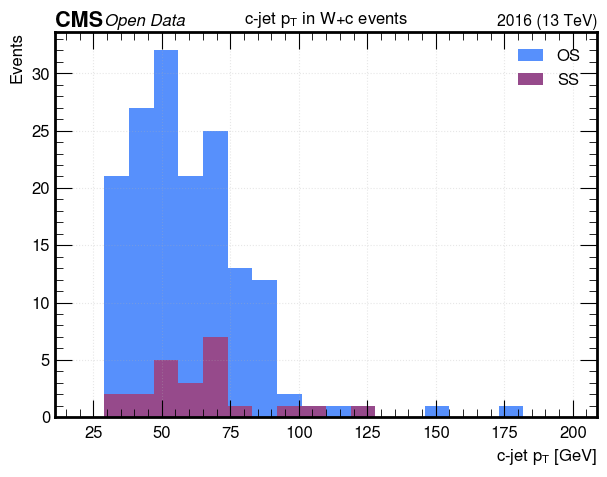

(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'center': 'c-jet $p_T$ in W+c events'}, xlabel='c-jet $p_T$ [GeV]', ylabel='Events'>,
 Hist(Regular(20, 20, 200, name='pt', label='c-jet $p_T$ [GeV]'), storage=Double()) # Sum: 157.0,
 Hist(Regular(20, 20, 200, name='pt', label='c-jet $p_T$ [GeV]'), storage=Double()) # Sum: 23.0)

In [12]:
evt_OS = dak.any(OS_pair, axis=1)
evt_SS = dak.any(SS_pair, axis=1)

WcMu_Pt_OS = dak.flatten(W_muons_wc.pt[evt_OS])
WcMu_Pt_SS = dak.flatten(W_muons_wc.pt[evt_SS])

make_overlay_hist(
    WcMu_Pt_OS, WcMu_Pt_SS,
    bins=20, x_range=(20, 200), name="pt",
    title=r"c-jet $p_T$ in W+c events",
    xlabel=r"c-jet $p_T$ [GeV]",
    ylabel="Events",
    labels=("OS", "SS"),
    colors=("C0", "C3"),
    normalize=False,
    histtype="bar",   
    fname="Plots/cjet_pt_OS_vs_SS.png",
)

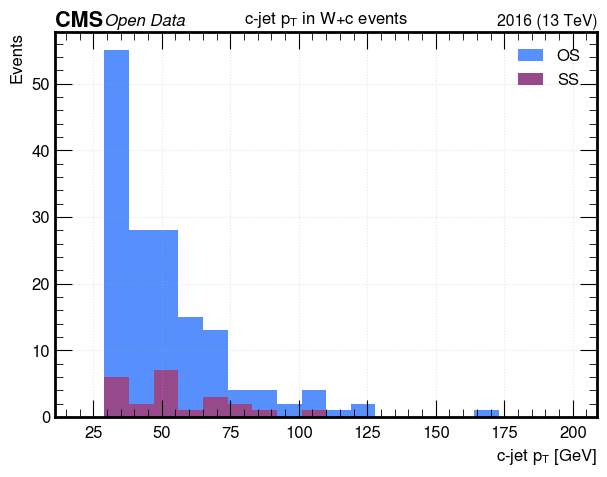

(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'center': 'c-jet $p_T$ in W+c events'}, xlabel='c-jet $p_T$ [GeV]', ylabel='Events'>,
 Hist(Regular(20, 20, 200, name='pt', label='c-jet $p_T$ [GeV]'), storage=Double()) # Sum: 157.0,
 Hist(Regular(20, 20, 200, name='pt', label='c-jet $p_T$ [GeV]'), storage=Double()) # Sum: 23.0)

In [13]:
make_overlay_hist(
    cjet_pt_OS, cjet_pt_SS,
    bins=20, x_range=(20, 200), name="pt",
    title=r"c-jet $p_T$ in W+c events",
    xlabel=r"c-jet $p_T$ [GeV]",
    ylabel="Events",
    labels=("OS", "SS"),
    colors=("C0", "C3"),
    normalize=False,
    histtype="bar",   
    fname="Plots/cjet_pt_OS_vs_SS.png",
)

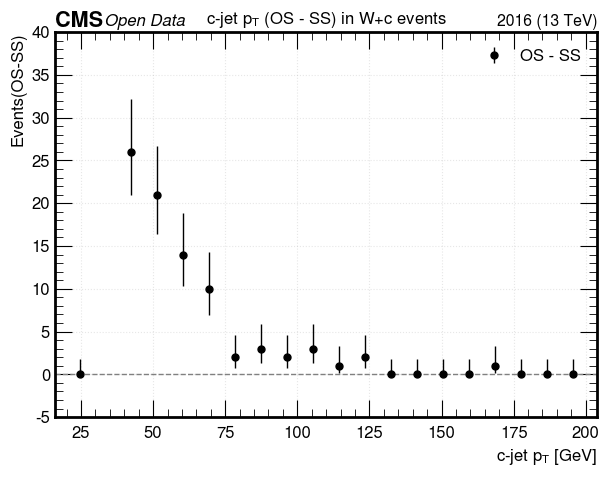

(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'center': 'c-jet $p_T$ (OS - SS) in W+c events'}, xlabel='c-jet $p_T$ [GeV]', ylabel='Events(OS-SS)'>,
 Hist(Regular(20, 20, 200, name='pt', label='c-jet $p_T$ [GeV]'), storage=Double()) # Sum: 134.0)

In [14]:
make_diff_hist(
    cjet_pt_OS,
    cjet_pt_SS,
    bins=20,
    lo=20,
    hi=200,
    ylo=-5,
    yhi=40,
    name="pt",
    xlabel=r"c-jet $p_T$ [GeV]",
    ylabel="Events(OS-SS)",
    title=r"c-jet $p_T$ (OS - SS) in W+c events",
    diff_label="OS - SS",
    color="k",
    histtype="errorbar",
    yerr=True,
    zero_line=True,
    normalize=False,
    fname="Plots/cjet_pt_diff.png"
)

## Background Events:

The backgrounds like W+cc, W+b, W+udsg are to calculated:

In [15]:
jets_Wc = events_wc.Jet
jet_passMask = (
    (jets_Wc.pt > 30) &
    (abs(jets_Wc.eta) < 2.4)
)
jets_Wc = jets_Wc[jet_passMask]

# Number of Hadron Flavor counts per events:
nC_hadron = dak.sum(jets_Wc.hadronFlavour == 4, axis=1)
nB_hadron = dak.sum(jets_Wc.hadronFlavour == 5, axis=1)

# W+cc, W+b, W+udsg event selections:
evt_Wcc = (nC_hadron >= 2) & (nB_hadron == 0)
evt_Wb = (nB_hadron >= 1) 
evt_Wudsg = (nC_hadron == 0) & (nB_hadron == 0) 

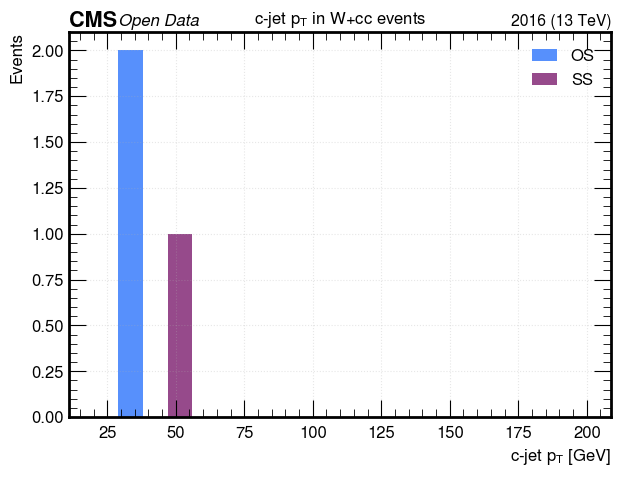

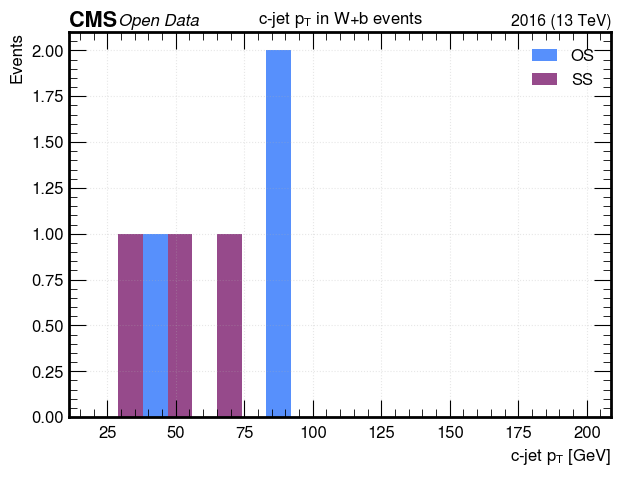

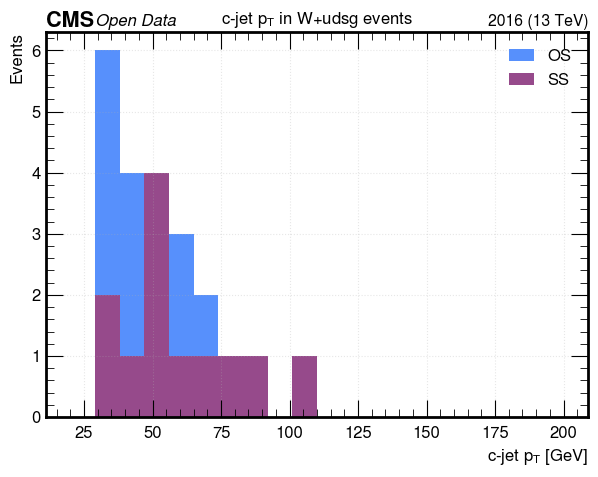

(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'center': 'c-jet $p_T$ in W+udsg events'}, xlabel='c-jet $p_T$ [GeV]', ylabel='Events'>,
 Hist(Regular(20, 20, 200, name='pt', label='c-jet $p_T$ [GeV]'), storage=Double()) # Sum: 18.0,
 Hist(Regular(20, 20, 200, name='pt', label='c-jet $p_T$ [GeV]'), storage=Double()) # Sum: 12.0)

In [16]:
# Assuming you already computed:
#   cJets_wc, OS_pair, SS_pair  (as in your OS/SS cell)

cjet_pt_OS_Wcc   = dak.flatten(cJets_wc.pt[OS_pair & evt_Wcc[:, None]])
cjet_pt_SS_Wcc   = dak.flatten(cJets_wc.pt[SS_pair & evt_Wcc[:, None]])

cjet_pt_OS_Wb    = dak.flatten(cJets_wc.pt[OS_pair & evt_Wb[:, None]])
cjet_pt_SS_Wb    = dak.flatten(cJets_wc.pt[SS_pair & evt_Wb[:, None]])

cjet_pt_OS_Wudsg = dak.flatten(cJets_wc.pt[OS_pair & evt_Wudsg[:, None]])
cjet_pt_SS_Wudsg = dak.flatten(cJets_wc.pt[SS_pair & evt_Wudsg[:, None]])

make_overlay_hist(
    cjet_pt_OS_Wcc, cjet_pt_SS_Wcc,
    bins=20, x_range=(20, 200), name="pt",
    title=r"c-jet $p_T$ in W+cc events",
    xlabel=r"c-jet $p_T$ [GeV]",
    ylabel="Events",
    labels=("OS", "SS"),
    colors=("C0", "C3"),
    normalize=False,
    histtype="bar",   
    fname="Plots/cjet_pt_OS_vs_SS_Wcc.png",
)

make_overlay_hist(
    cjet_pt_OS_Wb, cjet_pt_SS_Wb,
    bins=20, x_range=(20, 200), name="pt",
    title=r"c-jet $p_T$ in W+b events",
    xlabel=r"c-jet $p_T$ [GeV]",
    ylabel="Events",
    labels=("OS", "SS"),
    colors=("C0", "C3"),
    normalize=False,
    histtype="bar",   
    fname="Plots/cjet_pt_OS_vs_SS_Wb.png",
)

make_overlay_hist(
    cjet_pt_OS_Wudsg, cjet_pt_SS_Wudsg,
    bins=20, x_range=(20, 200), name="pt",
    title=r"c-jet $p_T$ in W+udsg events",
    xlabel=r"c-jet $p_T$ [GeV]",
    ylabel="Events",
    labels=("OS", "SS"),
    colors=("C0", "C3"),
    normalize=False,
    histtype="bar",   
    fname="Plots/cjet_pt_OS_vs_SS_Wudsg.png",
)

In [17]:
def os_ss_hist(x_os, x_ss, *, bins=20, lo=20, hi=200, name="pt", label=None, normalize=False):
    axis = h.axis.Regular(bins, lo, hi, name=name, label=(label if label else name))
    hOS_d = h.dask.Hist(axis)
    hSS_d = h.dask.Hist(axis)
    hOS_d.fill(**{name: x_os})
    hSS_d.fill(**{name: x_ss})
    hDiff = hOS_d.compute() - hSS_d.compute()
    if normalize:
        s = float(hDiff.values().sum())
        if s != 0:
            hDiff = hDiff / s
    return hDiff

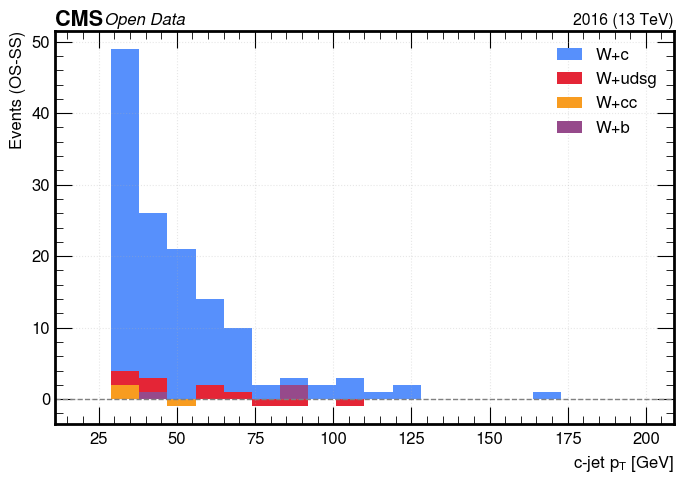

In [18]:
# build OS-SS shapes for each category (expects these arrays already exist) 
h_Wc    = os_ss_hist(cjet_pt_OS,      cjet_pt_SS,  bins=20, lo=20, hi=200, normalize=False)
h_Wcc   = os_ss_hist(cjet_pt_OS_Wcc,  cjet_pt_SS_Wcc,  bins=20, lo=20, hi=200, normalize=False)
h_Wb    = os_ss_hist(cjet_pt_OS_Wb,   cjet_pt_SS_Wb,   bins=20, lo=20, hi=200, normalize=False)
h_Wudsg = os_ss_hist(cjet_pt_OS_Wudsg,cjet_pt_SS_Wudsg,bins=20, lo=20, hi=200, normalize=False)

# Overlay plot 
fig, ax = plt.subplots(figsize=(7, 5))

mh.histplot(h_Wc,    ax=ax, label="W+c",    histtype="fill", linewidth=1.8, color="C0")
mh.histplot(h_Wudsg, ax=ax, label="W+udsg", histtype="fill", linewidth=1.8, color="C2")
mh.histplot(h_Wcc,   ax=ax, label="W+cc",   histtype="fill", linewidth=1.8, color="C1")
mh.histplot(h_Wb,    ax=ax, label="W+b",    histtype="fill", linewidth=1.8, color="C3")

mh.cms.label("Open Data", data=True, lumi=None, com=13, year=2016, loc=0)

ax.set_xlabel(r"c-jet $p_T$ [GeV]")
ax.set_ylabel("Events (OS-SS)")
ax.axhline(0.0, color="0.5", lw=1, ls="--")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig("Plots/cjet_pt_OSSS_overlay_Wc_Wcc_Wb_Wudsg.png")
plt.show()

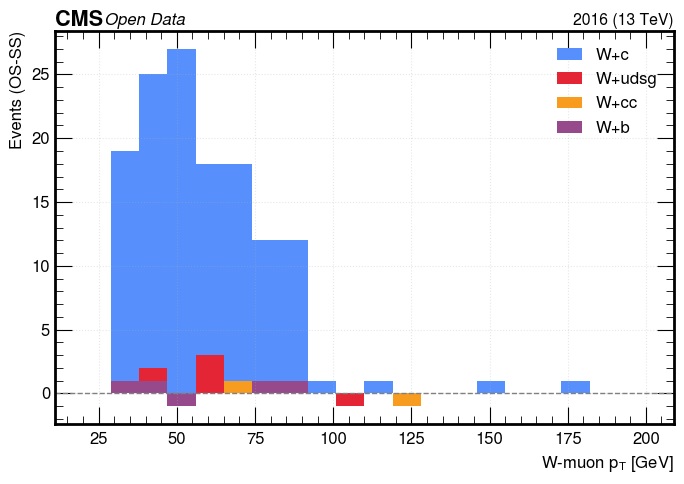

In [19]:
evt_OS = dak.any(OS_pair, axis=1)
evt_SS = dak.any(SS_pair, axis=1)

wmu_pt = W_muons_wc.pt[:, 0]  # scalar per event

wmu_pt_OS_Wc    = wmu_pt[evt_OS]
wmu_pt_SS_Wc    = wmu_pt[evt_SS]
wmu_pt_OS_Wcc   = wmu_pt[evt_OS & evt_Wcc]
wmu_pt_SS_Wcc   = wmu_pt[evt_SS & evt_Wcc]
wmu_pt_OS_Wb    = wmu_pt[evt_OS & evt_Wb]
wmu_pt_SS_Wb    = wmu_pt[evt_SS & evt_Wb]
wmu_pt_OS_Wudsg = wmu_pt[evt_OS & evt_Wudsg]
wmu_pt_SS_Wudsg = wmu_pt[evt_SS & evt_Wudsg]

h_Wc_wmu    = os_ss_hist(wmu_pt_OS_Wc,    wmu_pt_SS_Wc,    bins=20, lo=20, hi=200, name="pt", label=r"W-muon $p_T$ [GeV]")
h_Wcc_wmu   = os_ss_hist(wmu_pt_OS_Wcc,   wmu_pt_SS_Wcc,   bins=20, lo=20, hi=200, name="pt", label=r"W-muon $p_T$ [GeV]")
h_Wb_wmu    = os_ss_hist(wmu_pt_OS_Wb,    wmu_pt_SS_Wb,    bins=20, lo=20, hi=200, name="pt", label=r"W-muon $p_T$ [GeV]")
h_Wudsg_wmu = os_ss_hist(wmu_pt_OS_Wudsg, wmu_pt_SS_Wudsg, bins=20, lo=20, hi=200, name="pt", label=r"W-muon $p_T$ [GeV]")

fig, ax = plt.subplots(figsize=(7, 5))
mh.histplot(h_Wc_wmu,    ax=ax, label="W+c",    histtype="fill", lw=1.8, color="C0")
mh.histplot(h_Wudsg_wmu, ax=ax, label="W+udsg", histtype="fill", lw=1.8, color="C2")
mh.histplot(h_Wcc_wmu,   ax=ax, label="W+cc",   histtype="fill", lw=1.8, color="C1")
mh.histplot(h_Wb_wmu,    ax=ax, label="W+b",    histtype="fill", lw=1.8, color="C3")

mh.cms.label("Open Data", data=True, lumi=None, com=13, year=2016, loc=0)
ax.set_xlabel(r"W-muon $p_T$ [GeV]")
ax.set_ylabel("Events (OS-SS)")
ax.axhline(0.0, color="0.5", lw=1, ls="--")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("Plots/Wmu_pt_OSSS_overlay_Wc_Wcc_Wb_Wudsg.png")
plt.show()

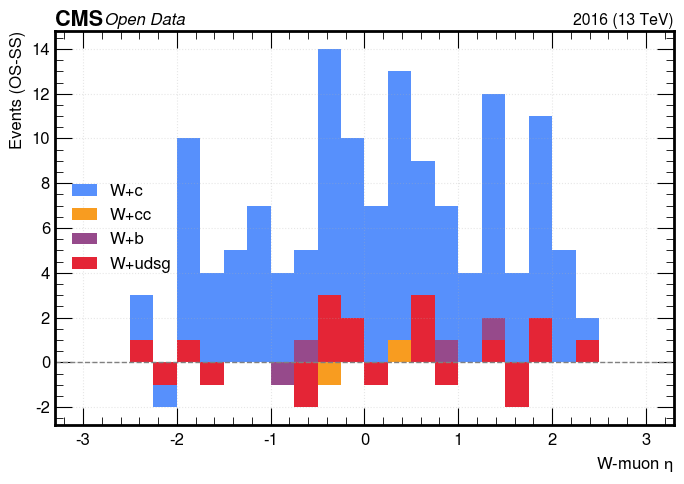

In [22]:
evt_OS = dak.any(OS_pair, axis=1)
evt_SS = dak.any(SS_pair, axis=1)

wmu_eta = W_muons_wc.eta[:, 0]  # scalar per event

wmu_eta_OS_Wc    = wmu_eta[evt_OS]
wmu_eta_SS_Wc    = wmu_eta[evt_SS]
wmu_eta_OS_Wcc   = wmu_eta[evt_OS & evt_Wcc]
wmu_eta_SS_Wcc   = wmu_eta[evt_SS & evt_Wcc]
wmu_eta_OS_Wb    = wmu_eta[evt_OS & evt_Wb]
wmu_eta_SS_Wb    = wmu_eta[evt_SS & evt_Wb]
wmu_eta_OS_Wudsg = wmu_eta[evt_OS & evt_Wudsg]
wmu_eta_SS_Wudsg = wmu_eta[evt_SS & evt_Wudsg]

h_Wc_eta    = os_ss_hist(wmu_eta_OS_Wc,    wmu_eta_SS_Wc,    bins=24, lo=-3.0, hi=3.0, name="eta", label=r"W-muon $\eta$", normalize=False)
h_Wcc_eta   = os_ss_hist(wmu_eta_OS_Wcc,   wmu_eta_SS_Wcc,   bins=24, lo=-3.0, hi=3.0, name="eta", label=r"W-muon $\eta$", normalize=False)
h_Wb_eta    = os_ss_hist(wmu_eta_OS_Wb,    wmu_eta_SS_Wb,    bins=24, lo=-3.0, hi=3.0, name="eta", label=r"W-muon $\eta$", normalize=False)
h_Wudsg_eta = os_ss_hist(wmu_eta_OS_Wudsg, wmu_eta_SS_Wudsg, bins=24, lo=-3.0, hi=3.0, name="eta", label=r"W-muon $\eta$", normalize=False)

fig, ax = plt.subplots(figsize=(7, 5))
mh.histplot(h_Wc_eta,    ax=ax, label="W+c",    histtype="fill", lw=1.8, color="C0")
mh.histplot(h_Wcc_eta,   ax=ax, label="W+cc",   histtype="fill", lw=1.8, color="C1")
mh.histplot(h_Wb_eta,    ax=ax, label="W+b",    histtype="fill", lw=1.8, color="C3")
mh.histplot(h_Wudsg_eta, ax=ax, label="W+udsg", histtype="fill", lw=1.8, color="C2")

mh.cms.label("Open Data", data=True, lumi=None, com=13, year=2016, loc=0)
ax.set_xlabel(r"W-muon $\eta$")
ax.set_ylabel("Events (OS-SS)")
ax.axhline(0.0, color="0.5", lw=1, ls="--")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig("Plots/Wmu_eta_OSSS_overlay_Wc_Wcc_Wb_Wudsg.png")
plt.show()